<img src ="https://datascienceBocconi.github.io/Images/Other/logoBocconi.png">

# **Senate IDEAL Point Model**

This notebook estimates revealed voting positions for current French senators with one model only: `pscl::ideal`.

We use public roll-call votes only. These are revealed positions in selected public votes, not complete ideology.

## **1. Setup and data**

We load the cleaned Senate data and the package needed for the IDEAL model.

In [1]:
options(repr.plot.width = 12, repr.plot.height = 8)
options(digits = 3)

library(tidyverse)
library(pscl)

theme_set(theme_bw())

Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”


Warning message:
“package ‘purrr’ was built under R version 4.5.3”


Warning message:
“package ‘dplyr’ was built under R version 4.5.3”


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Classes and Methods for R originally developed in the
Political Science Computational Laboratory
Department of Political Science
Stanford University (2002-2015),
by and under the direction of Simon Jackman.
hurdle and zeroinfl functions by Achim Zeileis.



In [2]:
data_folder <- "/Users/oscar/Documents/Bocconi/Projects/SENAT - ML- Project/senat_ml_clean_project/data/model_ready"

votes <- read_csv(file.path(data_folder, "votes_senateurs_actifs.csv"), show_col_types = FALSE)
senators <- read_csv(file.path(data_folder, "senateurs_actifs.csv"), show_col_types = FALSE)
rollcalls <- read_csv(file.path(data_folder, "scrutins_rollcalls.csv"), show_col_types = FALSE)

dim(votes)
dim(senators)
dim(rollcalls)

[1] 698455     20

[1] 348  20

[1] 4759   10

## **2. Prepare the roll-call matrix**

We follow the papers: keep current senators, yes/no votes, non-lopsided votes, and senators with at least 25 votes.

In [3]:
votes_active <- votes %>%
  semi_join(senators, by = "matricule")

votes_binary <- votes_active %>%
  filter(vote_value %in% c(1, -1)) %>%
  mutate(vote_model = if_else(vote_value == 1, 1, 0))

vote_balance <- votes_binary %>%
  group_by(scrutin_id) %>%
  summarise(
    yes_votes = sum(vote_model == 1),
    no_votes = sum(vote_model == 0),
    total_votes = n(),
    minority_share = pmin(yes_votes, no_votes) / total_votes,
    .groups = "drop"
  )

good_votes <- vote_balance %>%
  filter(minority_share >= 0.10)

votes_filtered <- votes_binary %>%
  semi_join(good_votes, by = "scrutin_id")

good_senators <- votes_filtered %>%
  count(matricule, name = "n_votes") %>%
  filter(n_votes >= 25)

votes_model <- votes_filtered %>%
  semi_join(good_senators, by = "matricule")

tibble(
  active_senators = length(unique(votes_active$matricule)),
  model_senators = length(unique(votes_model$matricule)),
  model_roll_calls = length(unique(votes_model$scrutin_id)),
  model_rows = nrow(votes_model)
)

active_senators,model_senators,model_roll_calls,model_rows
<int>,<int>,<int>,<int>
348,348,3558,482544


In [4]:
vote_matrix_data <- votes_model %>%
  select(matricule, scrutin_id, vote_model) %>%
  group_by(matricule, scrutin_id) %>%
  summarise(vote_model = first(vote_model), .groups = "drop") %>%
  pivot_wider(names_from = scrutin_id, values_from = vote_model) %>%
  arrange(matricule)

senator_ids <- as.character(vote_matrix_data$matricule)

vote_matrix <- vote_matrix_data %>%
  select(-matricule) %>%
  as.matrix()

rownames(vote_matrix) <- senator_ids
colnames(vote_matrix) <- make.names(colnames(vote_matrix), unique = TRUE)

senator_info <- tibble(matricule = senator_ids) %>%
  left_join(
    senators %>%
      mutate(matricule = as.character(matricule)) %>%
      select(matricule, nom, prenom, groupe_code, groupe_libelle_court),
    by = "matricule"
  ) %>%
  mutate(full_name = paste(prenom, nom))

senate_rollcall <- rollcall(
  vote_matrix,
  yea = 1,
  nay = 0,
  missing = NA,
  legis.names = senator_ids,
  vote.names = colnames(vote_matrix),
  legis.data = senator_info
)

summary(senate_rollcall)

Warning message:
“Setting row names on a tibble is deprecated.”


Warning message:
“Unknown or uninitialised column: `party`.”



Number of Legislators:		 348
Number of Roll Call Votes:	 3558


Using the following codes to represent roll call votes:
Yea:		 1 
Nay:		 0 
Abstentions:	 NA 
Not In Legislature:	 9 


Vote Summary:
         Count Percent
0 (nay) 260587      54
1 (yea) 221957      46

Use summary(senate_rollcall,verbose=TRUE) for more detailed information.

## **3. Shared plotting choices**

The models are not automatically left-right. We orient Dimension 1 after estimation, using group information only for interpretation.

In [5]:
left_groups <- c("SOC", "CRC", "GEST")
right_groups <- c("UMP", "UC", "RTLI")

group_order <- c("CRC", "GEST", "SOC", "RDSE", "LREM", "NI", "UC", "RTLI", "UMP")

group_colors <- c(
  "CRC" = "#B2182B",
  "GEST" = "#D6604D",
  "SOC" = "#EF8A62",
  "RDSE" = "#FDB863",
  "LREM" = "#A6D96A",
  "NI" = "#999999",
  "UC" = "#67A9CF",
  "RTLI" = "#2166AC",
  "UMP" = "#762A83"
)

target_senator_id <- "19057M"
target_senator_label <- "Samantha Cazebonne"

orient_and_scale <- function(points) {
  points <- points %>%
    left_join(senator_info, by = "matricule")

  left_mean <- points %>%
    filter(groupe_code %in% left_groups) %>%
    summarise(x = mean(dim1, na.rm = TRUE)) %>%
    pull(x)

  right_mean <- points %>%
    filter(groupe_code %in% right_groups) %>%
    summarise(x = mean(dim1, na.rm = TRUE)) %>%
    pull(x)

  if (left_mean > right_mean) {
    points$dim1 <- -points$dim1
  }

  radius <- max(sqrt(points$dim1^2 + points$dim2^2), na.rm = TRUE)

  points %>%
    mutate(
      dim1 = dim1 / radius,
      dim2 = dim2 / radius,
      groupe_code = factor(groupe_code, levels = group_order)
    )
}

plot_points <- function(points, title, subtitle) {
  target_point <- points %>%
    filter(matricule == target_senator_id)

  ggplot(points, aes(x = dim1, y = dim2, color = groupe_code)) +
    geom_hline(yintercept = 0, color = "grey85") +
    geom_vline(xintercept = 0, color = "grey85") +
    geom_point(alpha = 0.8, size = 2.5) +
    geom_point(
      data = target_point,
      aes(x = dim1, y = dim2),
      inherit.aes = FALSE,
      shape = 21,
      size = 5,
      stroke = 1.5,
      color = "black",
      fill = "#FFD400"
    ) +
    geom_label(
      data = target_point,
      aes(x = dim1, y = dim2, label = target_senator_label),
      inherit.aes = FALSE,
      nudge_y = 0.07,
      label.size = 0.25,
      size = 4,
      color = "black",
      fill = "white"
    ) +
    labs(
      title = title,
      subtitle = subtitle,
      x = "Dimension 1",
      y = "Dimension 2",
      color = "Group"
    ) +
    scale_color_manual(values = group_colors)
}

polarity_rows <- senator_info %>%
  mutate(row_number = row_number()) %>%
  filter(groupe_code %in% right_groups) %>%
  left_join(good_senators %>% mutate(matricule = as.character(matricule)), by = "matricule") %>%
  arrange(desc(n_votes)) %>%
  pull(row_number)

polarity_2d <- polarity_rows[1:2]
polarity_2d

[1] 1 4

## **4. Model 1: IDEAL**

This is a real Bayesian ideal point model from `pscl::ideal`. Missing votes stay missing.

In [6]:
set.seed(123)

ideal_model <- ideal(
  senate_rollcall,
  d = 2,
  maxiter = 1000,
  burnin = 500,
  thin = 25,
  impute = FALSE,
  store.item = FALSE,
  verbose = FALSE
)

points_ideal <- tibble(
  matricule = rownames(ideal_model$xbar),
  dim1 = ideal_model$xbar[, 1],
  dim2 = ideal_model$xbar[, 2]
) %>%
  orient_and_scale()

head(points_ideal)

ideal: analysis of roll call data via Markov chain Monte Carlo methods.

normalize option is only meaningful when d=1
Ideal Point Estimation

Number of Legislators		 348 
Number of Items			 3558 


Starting MCMC Iterations...



matricule,dim1,dim2,nom,prenom,groupe_code,groupe_libelle_court,full_name
<chr>,<dbl>,<dbl>,<chr>,<chr>,<fct>,<chr>,<chr>
01058X,0.713,-0.0485,Sido,Bruno,UMP,Les Républicains,Bruno Sido
04008A,0.773,-0.0900,Daubresse,Marc-Philippe,UMP,Les Républicains,Marc-Philippe Daubresse
04033B,0.669,0.0128,Retailleau,Bruno,UMP,Les Républicains,Bruno Retailleau
04042C,0.680,-0.0249,Cambon,Christian,UMP,Les Républicains,Christian Cambon
04045F,-0.343,0.8670,Schillinger,Patricia,LREM,RDPI,Patricia Schillinger
04047H,0.643,-0.0220,Buffet,François-Noël,UMP,Les Républicains,François-Noël Buffet


Warning message:
“The `label.size` argument of `geom_label()` is deprecated as of ggplot2 3.5.0.
ℹ Please use the `linewidth` argument instead.”


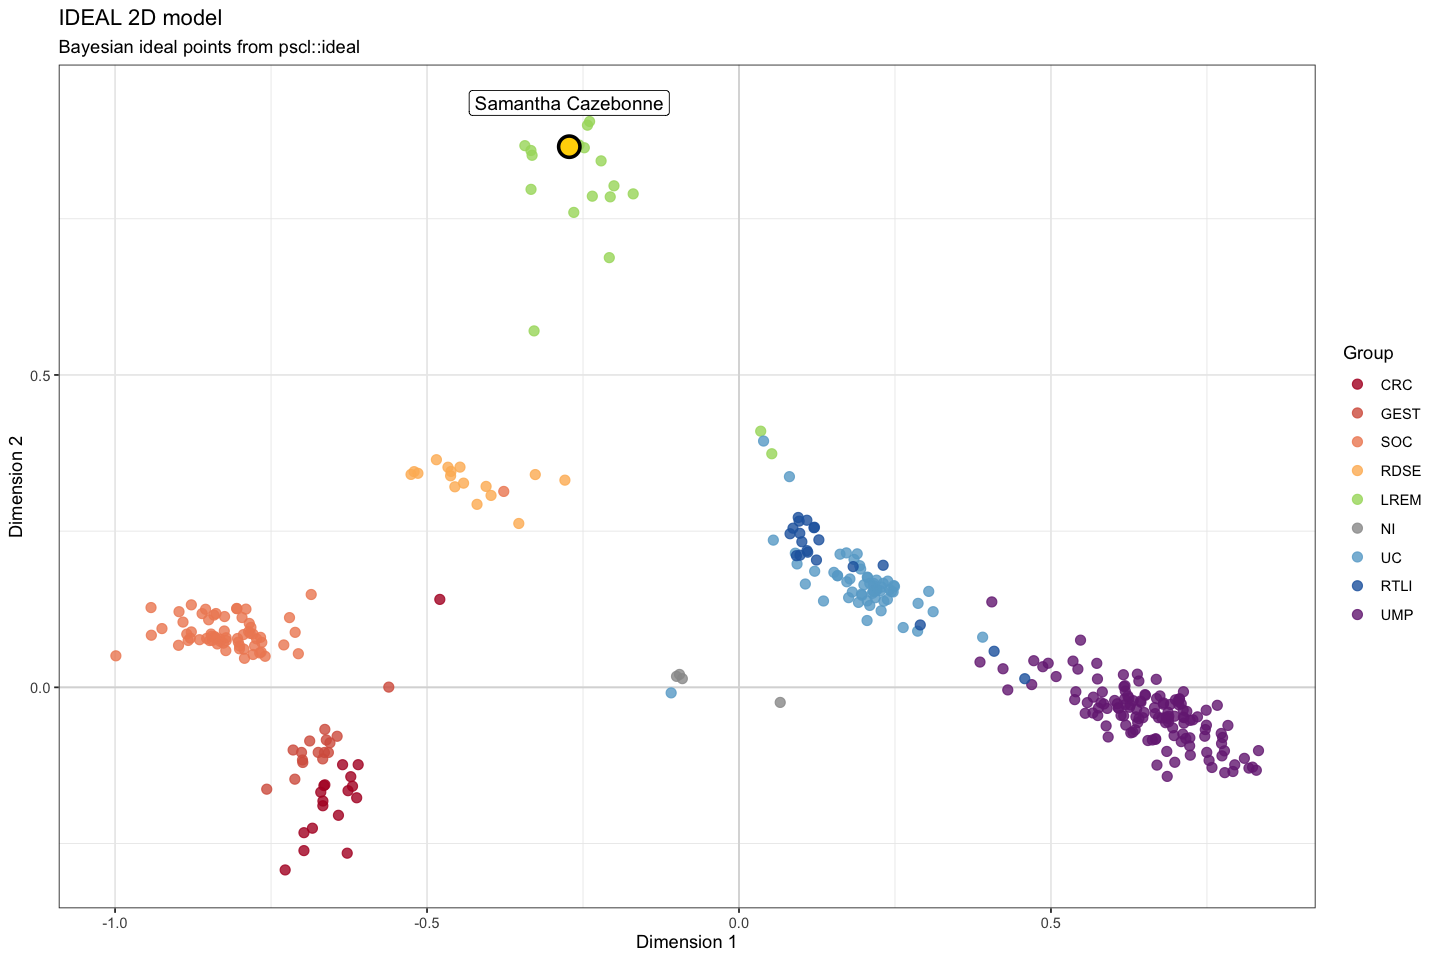

In [7]:
plot_points(
  points_ideal,
  "IDEAL 2D model",
  "Bayesian ideal points from pscl::ideal"
)

## **5. Weight the dimensions for distances**

The raw IDEAL map uses the two estimated coordinates directly.

For distances, it can make sense to give less weight to a weaker dimension. Here we measure each dimension by how well it classifies yes/no votes on its own. Then we shrink the weaker dimension before computing distances between senators.

In [8]:
majority_errors <- sum(apply(vote_matrix, 2, function(y) {
  y <- y[!is.na(y)]
  min(sum(y == 1), sum(y == 0))
}))

best_cutpoint_errors <- function(y, x) {
  keep <- !is.na(y) & !is.na(x)
  y <- y[keep]
  x <- x[keep]

  order_x <- order(x)
  y <- y[order_x]
  n <- length(y)
  best_errors <- n

  for (cut in 0:n) {
    predicted <- rep(0, n)
    if (cut < n) {
      predicted[(cut + 1):n] <- 1
    }
    best_errors <- min(best_errors, sum(predicted != y), sum((1 - predicted) != y))
  }

  best_errors
}

dimension_errors <- function(x) {
  total_errors <- 0

  for (j in 1:ncol(vote_matrix)) {
    total_errors <- total_errors + best_cutpoint_errors(vote_matrix[, j], x)
  }

  total_errors
}

dim1_errors <- dimension_errors(points_ideal$dim1)
dim2_errors <- dimension_errors(points_ideal$dim2)

dimension_weights <- tibble(
  dimension = c("Dimension 1", "Dimension 2"),
  classification_errors = c(dim1_errors, dim2_errors),
  correct_share = 1 - classification_errors / sum(!is.na(vote_matrix)),
  APRE = 1 - classification_errors / majority_errors
) %>%
  mutate(
    positive_APRE = pmax(APRE, 0),
    distance_weight = positive_APRE / max(positive_APRE),
    coordinate_multiplier = sqrt(distance_weight)
  )

dimension_weights

dimension,classification_errors,correct_share,APRE,positive_APRE,distance_weight,coordinate_multiplier
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dimension 1,16378,0.966,0.887,0.887,1.000,1.000
Dimension 2,104051,0.784,0.282,0.282,0.318,0.564


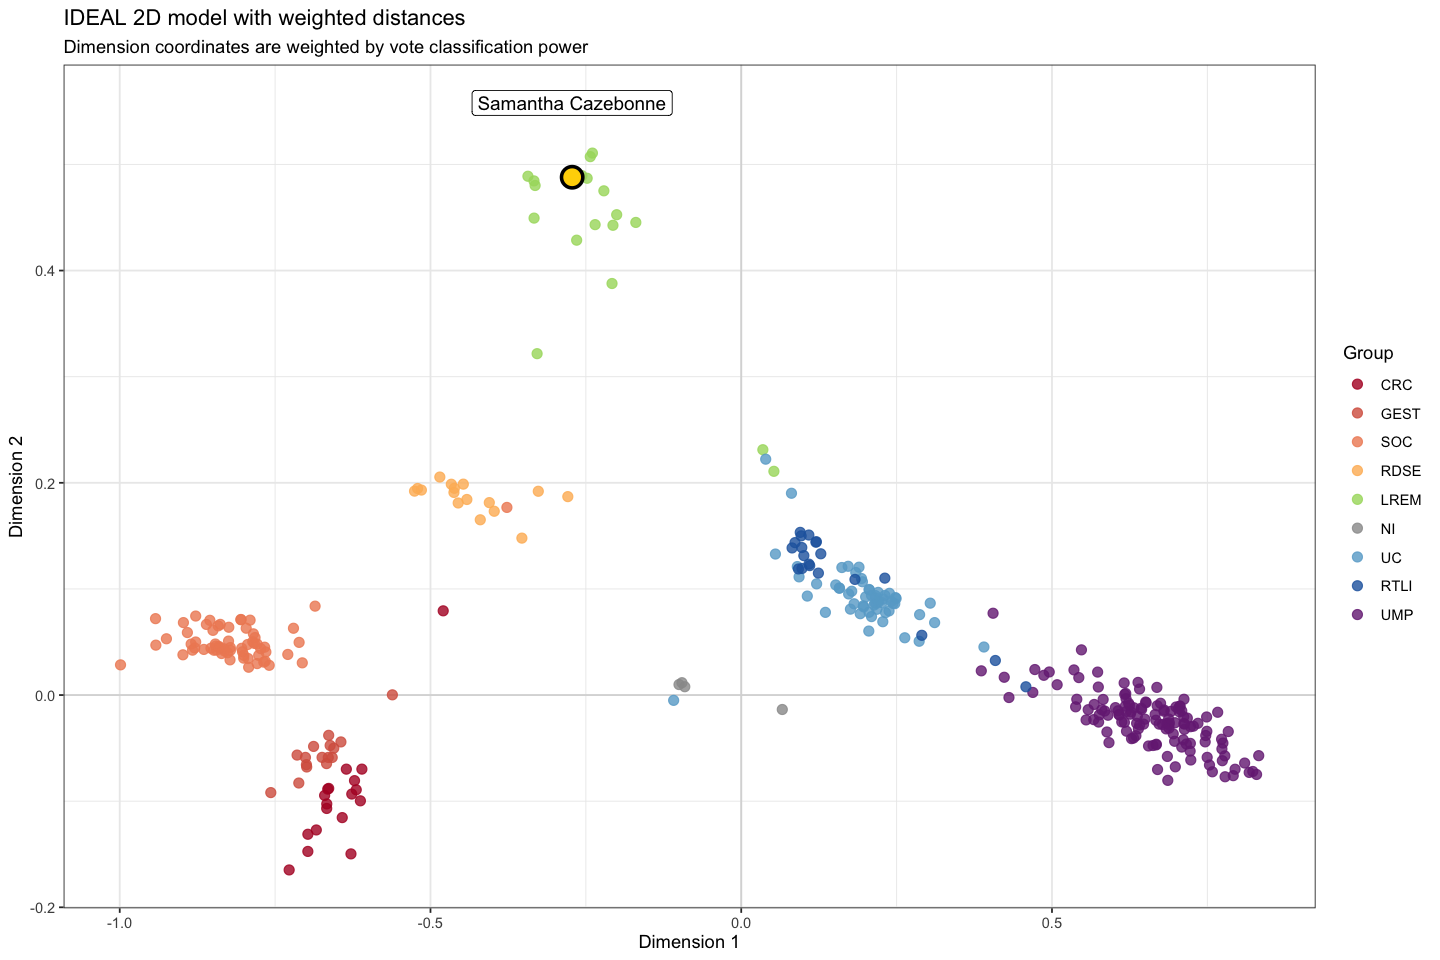

In [9]:
dim1_multiplier <- dimension_weights$coordinate_multiplier[dimension_weights$dimension == "Dimension 1"]
dim2_multiplier <- dimension_weights$coordinate_multiplier[dimension_weights$dimension == "Dimension 2"]

points_ideal_weighted <- points_ideal %>%
  mutate(
    dim1 = dim1 * dim1_multiplier,
    dim2 = dim2 * dim2_multiplier
  )

plot_points(
  points_ideal_weighted,
  "IDEAL 2D model with weighted distances",
  "Dimension coordinates are weighted by vote classification power"
)

## **6. One-dimensional view**

This keeps only Dimension 1, the main revealed voting axis.

This view is easier to explain to a non-technical audience: senators on the left vote more similarly to the left-side groups, and senators on the right vote more similarly to the right-side groups.

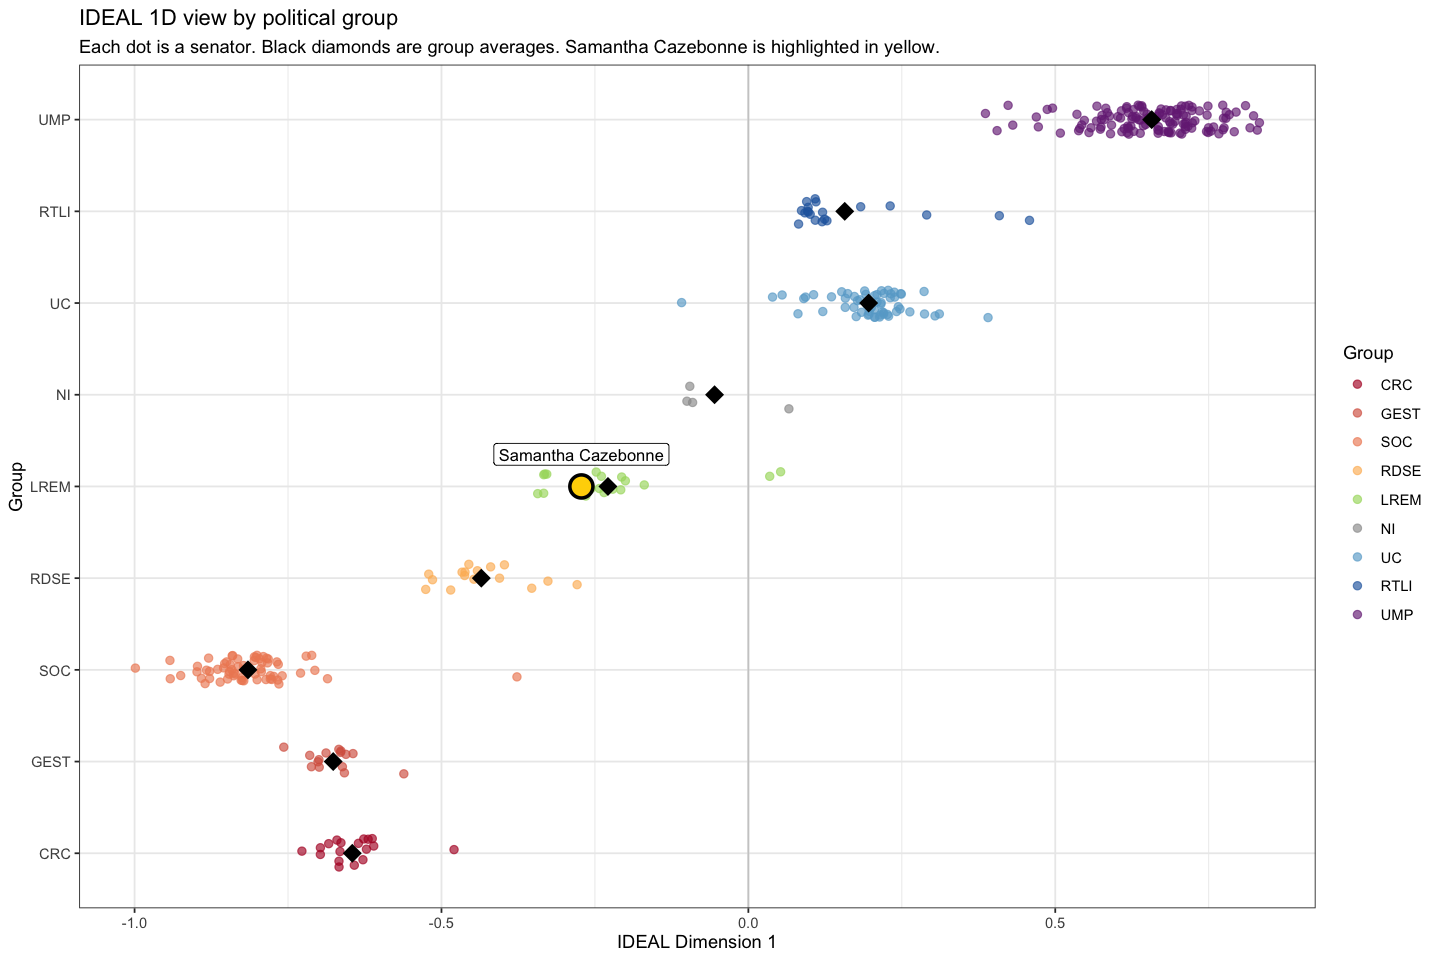

In [10]:
ideal_1d_points <- points_ideal %>%
  mutate(
    group = factor(groupe_code, levels = group_order),
    is_samantha = matricule == target_senator_id
  )

samantha_1d <- ideal_1d_points %>%
  filter(is_samantha)

ggplot(ideal_1d_points, aes(x = dim1, y = group, color = group)) +
  geom_vline(xintercept = 0, color = "grey80") +
  geom_jitter(height = 0.16, width = 0, alpha = 0.65, size = 2) +
  stat_summary(
    fun = mean,
    geom = "point",
    shape = 18,
    size = 5,
    color = "black"
  ) +
  geom_point(
    data = samantha_1d,
    aes(x = dim1, y = group),
    inherit.aes = FALSE,
    shape = 21,
    size = 5.5,
    stroke = 1.5,
    color = "black",
    fill = "#FFD400"
  ) +
  geom_label(
    data = samantha_1d,
    aes(x = dim1, y = group, label = target_senator_label),
    inherit.aes = FALSE,
    nudge_y = 0.35,
    label.size = 0.25,
    size = 3.5,
    color = "black",
    fill = "white"
  ) +
  labs(
    title = "IDEAL 1D view by political group",
    subtitle = "Each dot is a senator. Black diamonds are group averages. Samantha Cazebonne is highlighted in yellow.",
    x = "IDEAL Dimension 1",
    y = "Group",
    color = "Group"
  ) +
  scale_color_manual(values = group_colors)

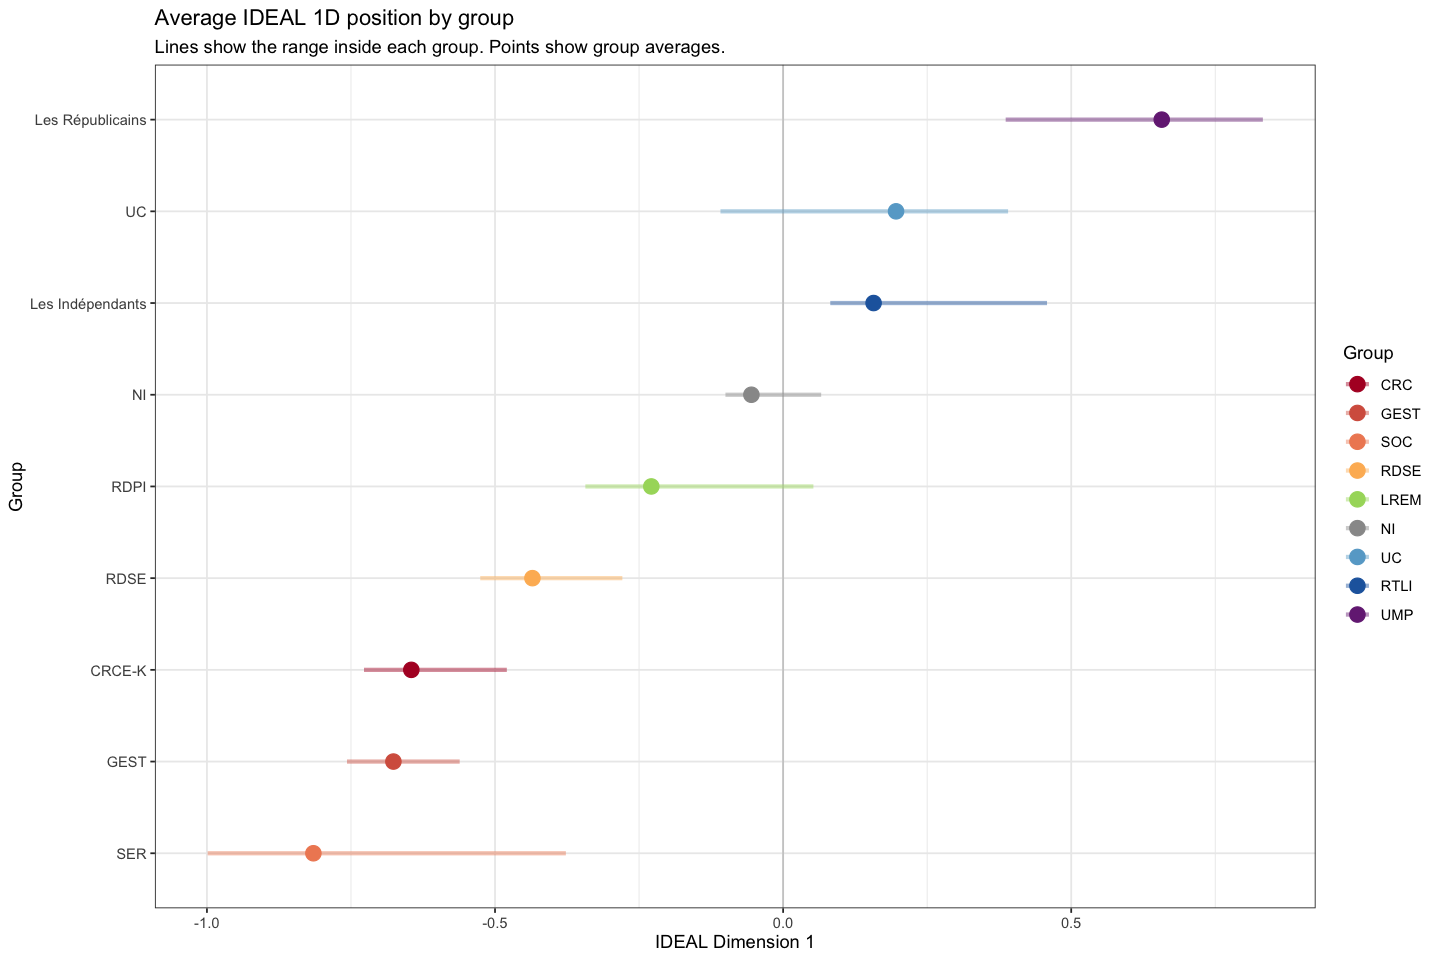

In [11]:
group_1d_summary <- ideal_1d_points %>%
  group_by(group, groupe_libelle_court) %>%
  summarise(
    senators = n(),
    average_dim1 = mean(dim1, na.rm = TRUE),
    median_dim1 = median(dim1, na.rm = TRUE),
    min_dim1 = min(dim1, na.rm = TRUE),
    max_dim1 = max(dim1, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(average_dim1)

ggplot(group_1d_summary, aes(x = average_dim1, y = reorder(groupe_libelle_court, average_dim1), color = group)) +
  geom_vline(xintercept = 0, color = "grey80") +
  geom_segment(aes(x = min_dim1, xend = max_dim1, yend = reorder(groupe_libelle_court, average_dim1)), linewidth = 1.2, alpha = 0.45) +
  geom_point(size = 4) +
  labs(
    title = "Average IDEAL 1D position by group",
    subtitle = "Lines show the range inside each group. Points show group averages.",
    x = "IDEAL Dimension 1",
    y = "Group",
    color = "Group"
  ) +
  scale_color_manual(values = group_colors)

In [12]:
closest_to_samantha_1d <- ideal_1d_points %>%
  mutate(distance_to_samantha_1d = abs(dim1 - samantha_1d$dim1[1])) %>%
  filter(matricule != target_senator_id) %>%
  arrange(distance_to_samantha_1d) %>%
  slice_head(n = 12) %>%
  mutate(full_name = reorder(full_name, distance_to_samantha_1d))

closest_to_samantha_1d %>%
  transmute(
    full_name,
    group = groupe_libelle_court,
    dim1 = round(dim1, 3),
    distance_to_samantha_1d = round(distance_to_samantha_1d, 3)
  )

full_name,group,dim1,distance_to_samantha_1d
<fct>,<chr>,<dbl>,<dbl>
Nathalie Delattre,RDSE,-0.279,0.007
Marie-Laure Phinera-Horth,RDPI,-0.265,0.007
Teva Rohfritsch,RDPI,-0.256,0.016
Bernard Buis,RDPI,-0.248,0.024
Dominique Théophile,RDPI,-0.243,0.029
Didier Rambaud,RDPI,-0.239,0.033
Nadège Havet,RDPI,-0.235,0.037
Mikaele Kulimoetoke,RDPI,-0.221,0.051
Bernard Fialaire,RDSE,-0.327,0.054


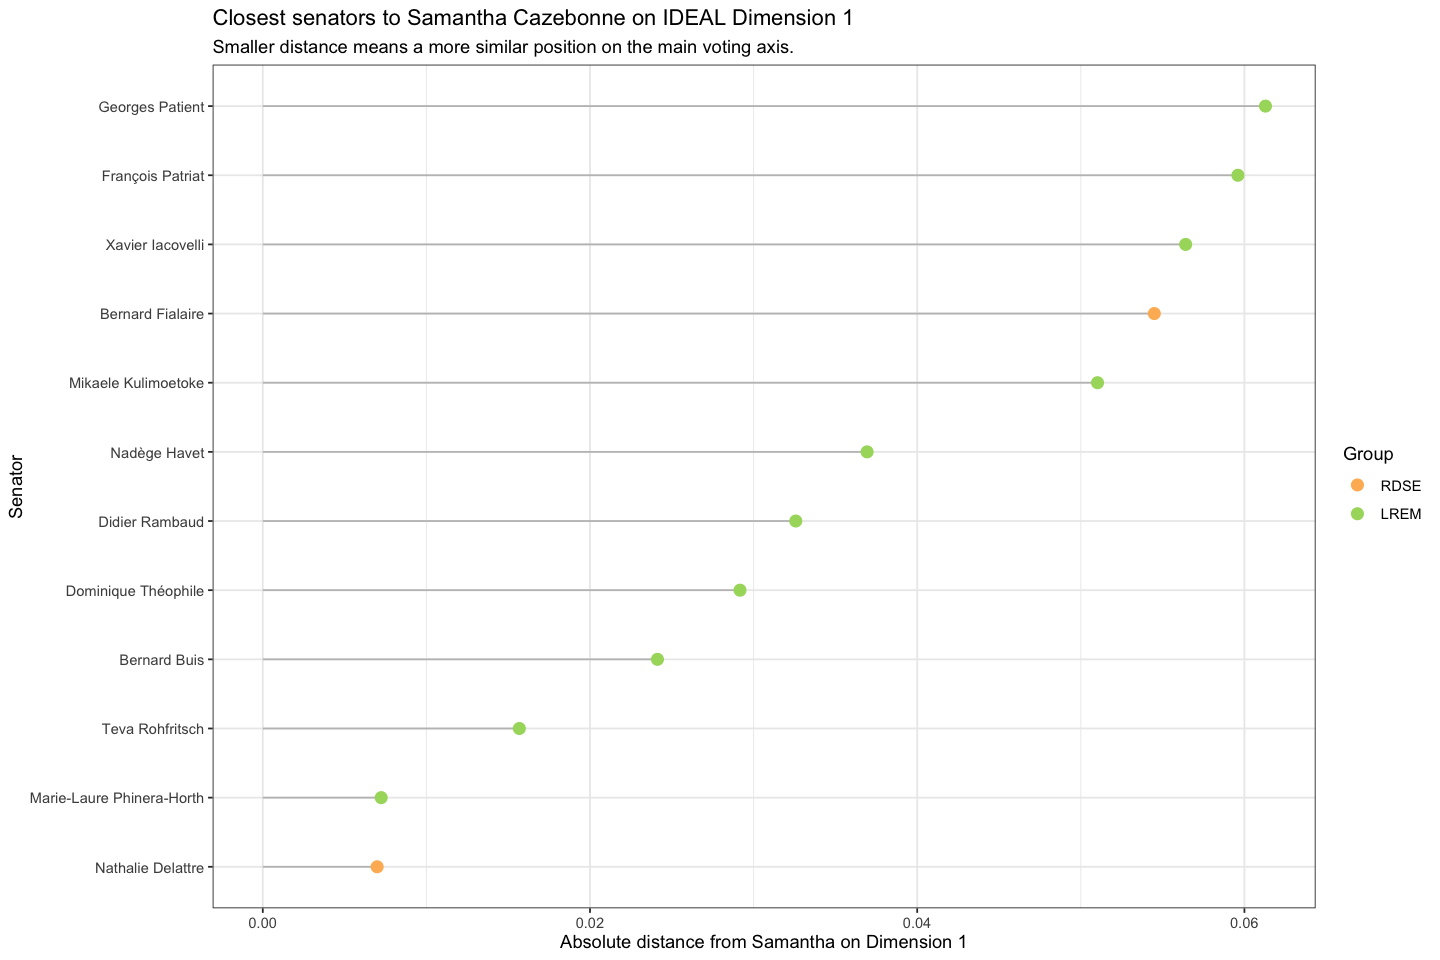

In [13]:
ggplot(closest_to_samantha_1d, aes(x = distance_to_samantha_1d, y = full_name, color = groupe_code)) +
  geom_segment(aes(x = 0, xend = distance_to_samantha_1d, yend = full_name), color = "grey75") +
  geom_point(size = 3) +
  labs(
    title = "Closest senators to Samantha Cazebonne on IDEAL Dimension 1",
    subtitle = "Smaller distance means a more similar position on the main voting axis.",
    x = "Absolute distance from Samantha on Dimension 1",
    y = "Senator",
    color = "Group"
  ) +
  scale_color_manual(values = group_colors)

## **7. Focus on Samantha Cazebonne**

This part follows Samantha Cazebonne specifically, because the project is for her and her team.

We compare her to senators in her group using the weighted IDEAL distances, then look at her vote participation and abstention profile.

In [14]:
samantha_identity <- senator_info %>%
  filter(matricule == target_senator_id) %>%
  left_join(
    senators %>%
      mutate(matricule = as.character(matricule)) %>%
      select(matricule, circonscription_libelle),
    by = "matricule"
  ) %>%
  select(full_name, groupe_code, groupe_libelle_court, circonscription_libelle)

samantha_identity

full_name,groupe_code,groupe_libelle_court,circonscription_libelle
<chr>,<chr>,<chr>,<chr>
Samantha Cazebonne,LREM,RDPI,Français établis hors de France (Série 2)


In [15]:
ideal_points_for_focus <- points_ideal_weighted %>%
  mutate(model = "IDEAL weighted distance")

samantha_model_position <- ideal_points_for_focus %>%
  group_by(groupe_code) %>%
  mutate(
    group_members = n(),
    rank_left_to_right = rank(dim1, ties.method = "average"),
    percentile_left_to_right = percent_rank(dim1)
  ) %>%
  ungroup() %>%
  group_by(groupe_code) %>%
  mutate(
    group_dim1_mean = mean(dim1, na.rm = TRUE),
    group_dim2_mean = mean(dim2, na.rm = TRUE),
    distance_to_group_center = sqrt((dim1 - group_dim1_mean)^2 + (dim2 - group_dim2_mean)^2)
  ) %>%
  ungroup() %>%
  filter(matricule == target_senator_id) %>%
  transmute(
    model,
    group = groupe_libelle_court,
    group_members,
    weighted_dim1 = round(dim1, 3),
    weighted_dim2 = round(dim2, 3),
    group_weighted_dim1_mean = round(group_dim1_mean, 3),
    group_weighted_dim2_mean = round(group_dim2_mean, 3),
    rank_left_to_right = round(rank_left_to_right, 1),
    percentile_left_to_right = round(percentile_left_to_right, 3),
    weighted_distance_to_group_center = round(distance_to_group_center, 3)
  )

samantha_model_position

model,group,group_members,weighted_dim1,weighted_dim2,group_weighted_dim1_mean,group_weighted_dim2_mean,rank_left_to_right,percentile_left_to_right,weighted_distance_to_group_center
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
IDEAL weighted distance,RDPI,19,-0.272,0.488,-0.229,0.433,6,0.278,0.07


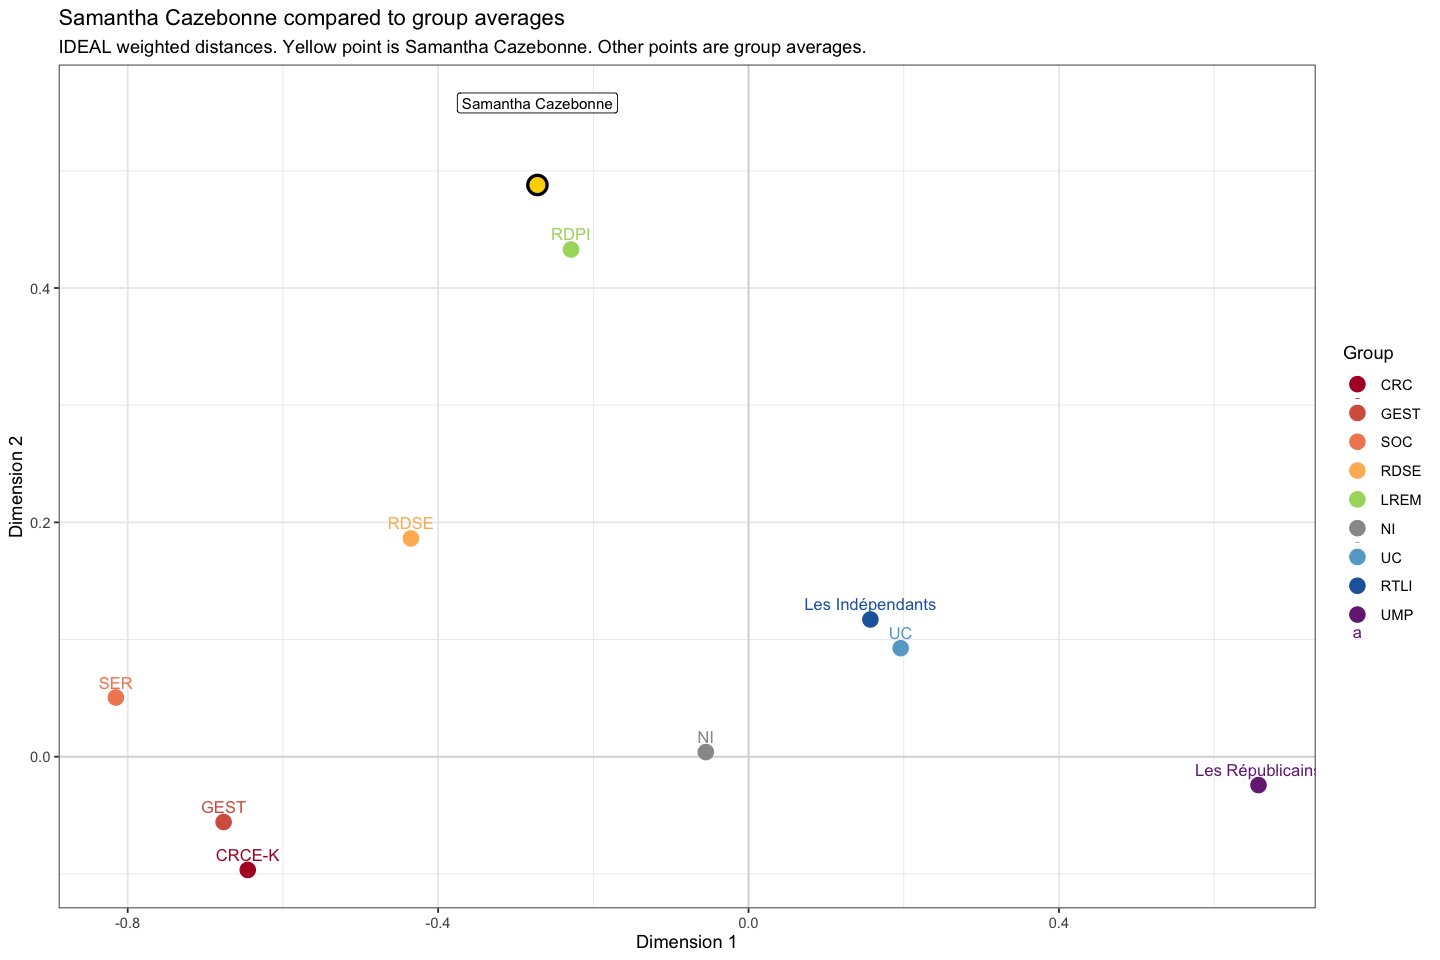

In [16]:
group_average_positions <- ideal_points_for_focus %>%
  group_by(groupe_code, groupe_libelle_court) %>%
  summarise(
    senators = n(),
    average_dim1 = mean(dim1, na.rm = TRUE),
    average_dim2 = mean(dim2, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(groupe_code = factor(groupe_code, levels = group_order))

ggplot(group_average_positions, aes(x = average_dim1, y = average_dim2, color = groupe_code)) +
  geom_hline(yintercept = 0, color = "grey85") +
  geom_vline(xintercept = 0, color = "grey85") +
  geom_point(size = 4) +
  geom_text(aes(label = groupe_libelle_court), vjust = -0.8, size = 3.5) +
  geom_point(
    data = points_ideal_weighted %>% filter(matricule == target_senator_id),
    aes(x = dim1, y = dim2),
    inherit.aes = FALSE,
    shape = 21,
    size = 4.5,
    stroke = 1.4,
    color = "black",
    fill = "#FFD400"
  ) +
  geom_label(
    data = points_ideal_weighted %>% filter(matricule == target_senator_id),
    aes(x = dim1, y = dim2, label = target_senator_label),
    inherit.aes = FALSE,
    nudge_y = 0.07,
    size = 3.2,
    color = "black",
    fill = "white"
  ) +
  labs(
    title = "Samantha Cazebonne compared to group averages",
    subtitle = "IDEAL weighted distances. Yellow point is Samantha Cazebonne. Other points are group averages.",
    x = "Dimension 1",
    y = "Dimension 2",
    color = "Group"
  ) +
  scale_color_manual(values = group_colors)

In [17]:
vote_profile <- votes_active %>%
  mutate(matricule = as.character(matricule)) %>%
  group_by(matricule, groupe_code, groupe_libelle_court) %>%
  summarise(
    total_public_votes = n(),
    yes_votes = sum(position == "pour", na.rm = TRUE),
    no_votes = sum(position == "contre", na.rm = TRUE),
    abstentions = sum(position == "abstention", na.rm = TRUE),
    non_voting = sum(position == "non-votant", na.rm = TRUE),
    abstention_rate = abstentions / total_public_votes,
    non_voting_rate = non_voting / total_public_votes,
    yes_no_share = (yes_votes + no_votes) / total_public_votes,
    .groups = "drop"
  )

samantha_vote_profile <- vote_profile %>%
  filter(matricule == target_senator_id)

group_vote_profile <- vote_profile %>%
  filter(groupe_code == samantha_vote_profile$groupe_code[1]) %>%
  summarise(
    group_members = n(),
    group_mean_abstention_rate = mean(abstention_rate, na.rm = TRUE),
    group_median_abstention_rate = median(abstention_rate, na.rm = TRUE),
    group_mean_non_voting_rate = mean(non_voting_rate, na.rm = TRUE),
    group_mean_yes_no_share = mean(yes_no_share, na.rm = TRUE)
  )

samantha_abstention_summary <- samantha_vote_profile %>%
  mutate(
    rank_abstention_in_group = rank(
      vote_profile$abstention_rate[vote_profile$groupe_code == groupe_code],
      ties.method = "average"
    )[which(vote_profile$matricule[vote_profile$groupe_code == groupe_code] == target_senator_id)]
  ) %>%
  bind_cols(group_vote_profile) %>%
  transmute(
    group = groupe_libelle_court,
    total_public_votes,
    yes_votes,
    no_votes,
    abstentions,
    non_voting,
    abstention_rate = round(abstention_rate, 3),
    group_mean_abstention_rate = round(group_mean_abstention_rate, 3),
    non_voting_rate = round(non_voting_rate, 3),
    group_mean_non_voting_rate = round(group_mean_non_voting_rate, 3),
    yes_no_share = round(yes_no_share, 3),
    group_mean_yes_no_share = round(group_mean_yes_no_share, 3),
    rank_abstention_in_group,
    group_members
  )

samantha_abstention_summary

group,total_public_votes,yes_votes,no_votes,abstentions,non_voting,abstention_rate,group_mean_abstention_rate,non_voting_rate,group_mean_non_voting_rate,yes_no_share,group_mean_yes_no_share,rank_abstention_in_group,group_members
<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
RDPI,1368,589,644,120,15,0.088,0.084,0.011,0.013,0.901,0.902,11,19


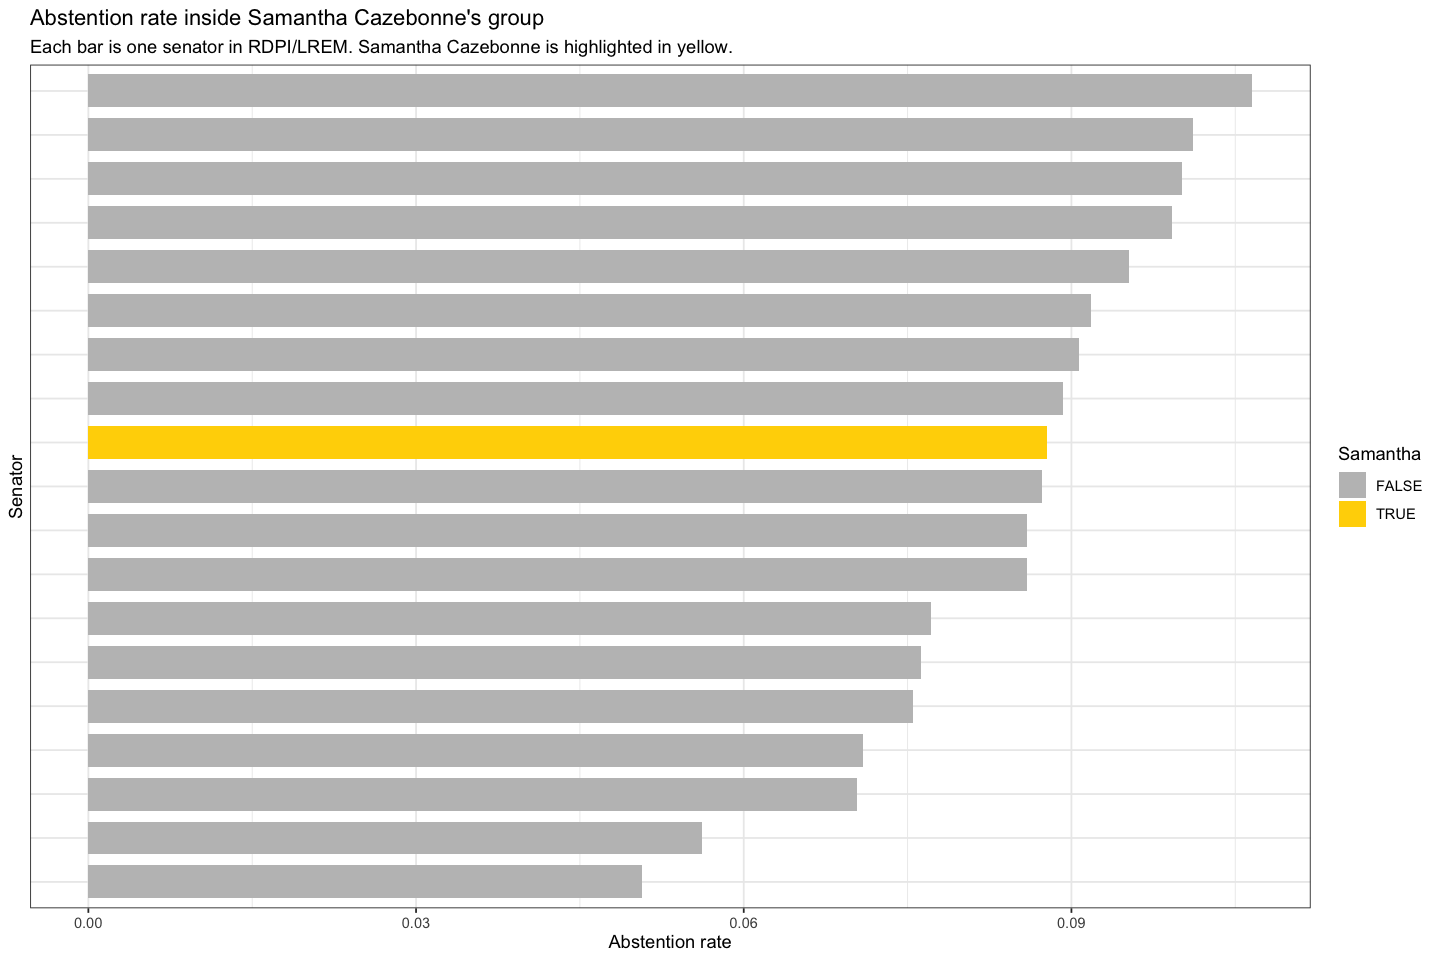

In [18]:
vote_profile %>%
  filter(groupe_code == samantha_vote_profile$groupe_code[1]) %>%
  mutate(is_samantha = matricule == target_senator_id) %>%
  ggplot(aes(x = reorder(matricule, abstention_rate), y = abstention_rate)) +
  geom_col(aes(fill = is_samantha), width = 0.75) +
  coord_flip() +
  scale_fill_manual(values = c("FALSE" = "grey75", "TRUE" = "#FFD400")) +
  labs(
    title = "Abstention rate inside Samantha Cazebonne's group",
    subtitle = "Each bar is one senator in RDPI/LREM. Samantha Cazebonne is highlighted in yellow.",
    x = "Senator",
    y = "Abstention rate",
    fill = "Samantha"
  ) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())

### **Group loyalty inside RDPI/LREM**

Here, loyalty means voting with the majority of Samantha Cazebonne's own group on yes/no votes.

Abstentions and non-votes are not counted as loyal or disloyal in this measure. They are shown separately above.

In [19]:
samantha_group_code <- samantha_vote_profile$groupe_code[1]

group_binary_votes <- votes_active %>%
  mutate(matricule = as.character(matricule)) %>%
  filter(
    groupe_code == samantha_group_code,
    position %in% c("pour", "contre")
  ) %>%
  mutate(vote_binary = if_else(position == "pour", 1, 0)) %>%
  group_by(scrutin_id) %>%
  mutate(
    group_yes = sum(vote_binary == 1),
    group_no = sum(vote_binary == 0),
    group_majority = case_when(
      group_yes > group_no ~ 1,
      group_no > group_yes ~ 0,
      TRUE ~ NA_real_
    )
  ) %>%
  ungroup() %>%
  filter(!is.na(group_majority))

party_fidelity <- group_binary_votes %>%
  group_by(matricule, nom, prenom, groupe_code, groupe_libelle_court) %>%
  summarise(
    yes_no_votes_with_group_majority = n(),
    votes_with_group = sum(vote_binary == group_majority),
    votes_against_group = sum(vote_binary != group_majority),
    group_loyalty_rate = votes_with_group / yes_no_votes_with_group_majority,
    .groups = "drop"
  ) %>%
  mutate(
    full_name = paste(prenom, nom),
    is_samantha = matricule == target_senator_id
  ) %>%
  left_join(
    vote_profile %>%
      select(matricule, abstention_rate, non_voting_rate),
    by = "matricule"
  ) %>%
  arrange(desc(group_loyalty_rate))

samantha_fidelity <- party_fidelity %>%
  filter(matricule == target_senator_id) %>%
  mutate(
    rank_most_loyal = rank(-party_fidelity$group_loyalty_rate, ties.method = "average")[party_fidelity$matricule == target_senator_id],
    group_members = nrow(party_fidelity)
  ) %>%
  transmute(
    full_name,
    group = groupe_libelle_court,
    yes_no_votes_with_group_majority,
    votes_with_group,
    votes_against_group,
    group_loyalty_rate = round(group_loyalty_rate, 3),
    abstention_rate = round(abstention_rate, 3),
    non_voting_rate = round(non_voting_rate, 3),
    rank_most_loyal,
    group_members
  )

samantha_fidelity

full_name,group,yes_no_votes_with_group_majority,votes_with_group,votes_against_group,group_loyalty_rate,abstention_rate,non_voting_rate,rank_most_loyal,group_members
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Samantha Cazebonne,RDPI,1231,1225,6,0.995,0.088,0.011,6,19


In [20]:
most_loyal <- party_fidelity %>%
  arrange(desc(group_loyalty_rate), desc(yes_no_votes_with_group_majority)) %>%
  slice_head(n = 5) %>%
  mutate(category = "Most loyal")

least_loyal <- party_fidelity %>%
  arrange(group_loyalty_rate, desc(yes_no_votes_with_group_majority)) %>%
  slice_head(n = 5) %>%
  mutate(category = "Least loyal")

bind_rows(most_loyal, least_loyal) %>%
  transmute(
    category,
    full_name,
    group = groupe_libelle_court,
    yes_no_votes_with_group_majority,
    votes_against_group,
    group_loyalty_rate = round(group_loyalty_rate, 3),
    abstention_rate = round(abstention_rate, 3),
    is_samantha
  )

category,full_name,group,yes_no_votes_with_group_majority,votes_against_group,group_loyalty_rate,abstention_rate,is_samantha
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<lgl>
Most loyal,Thani Mohamed Soilihi,RDPI,2969,5,0.998,0.076,FALSE
Most loyal,François Patriat,RDPI,4093,8,0.998,0.070,FALSE
Most loyal,Mikaele Kulimoetoke,RDPI,1399,4,0.997,0.092,FALSE
Most loyal,Patricia Schillinger,RDPI,4350,14,0.997,0.071,FALSE
Most loyal,Didier Rambaud,RDPI,1918,9,0.995,0.086,FALSE
Least loyal,Jean-Baptiste Lemoyne,RDPI,1905,528,0.723,0.056,FALSE
Least loyal,Nicole Duranton,RDPI,2767,666,0.759,0.051,FALSE
Least loyal,Xavier Iacovelli,RDPI,1825,186,0.898,0.099,FALSE
Least loyal,Solanges Nadille,RDPI,780,33,0.958,0.107,FALSE


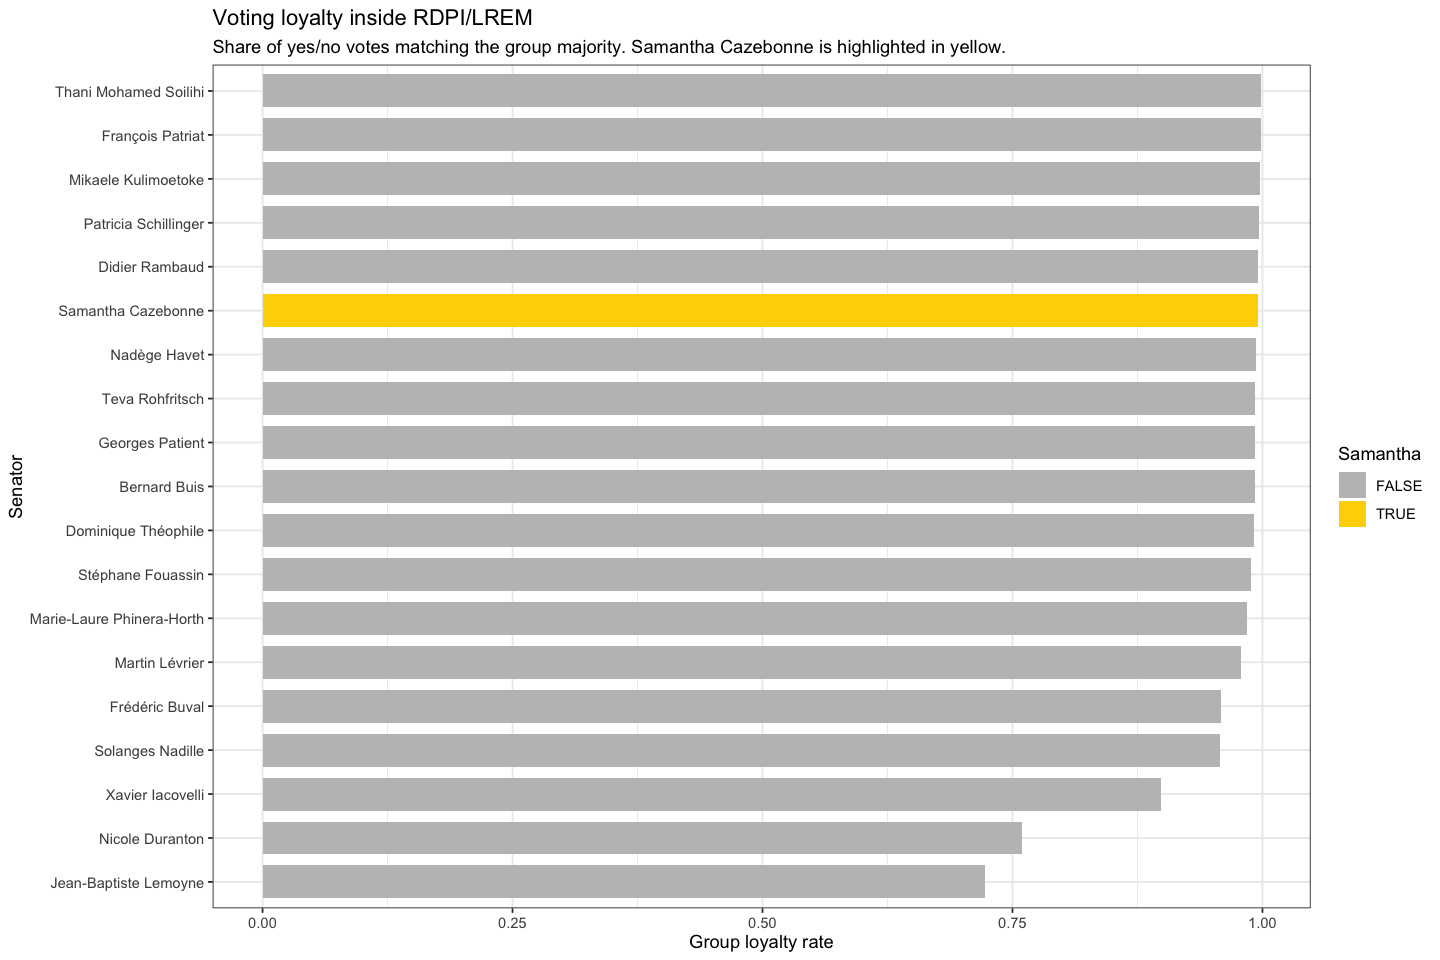

In [21]:
party_fidelity %>%
  mutate(full_name = reorder(full_name, group_loyalty_rate)) %>%
  ggplot(aes(x = full_name, y = group_loyalty_rate)) +
  geom_col(aes(fill = is_samantha), width = 0.75) +
  coord_flip() +
  scale_fill_manual(values = c("FALSE" = "grey75", "TRUE" = "#FFD400")) +
  labs(
    title = "Voting loyalty inside RDPI/LREM",
    subtitle = "Share of yes/no votes matching the group majority. Samantha Cazebonne is highlighted in yellow.",
    x = "Senator",
    y = "Group loyalty rate",
    fill = "Samantha"
  )

## **Conclusion**

This notebook keeps only the IDEAL model.

The 2D plot shows the raw revealed voting space. La deuxième dimension peut représenter le soutien au gouvernement: plus on est haut, plus on est proche de celui-ci; plus on est bas, plus on en est éloigné. The weighted distance plot shrinks weaker dimensions using their vote classification power. The 1D view gives a simpler explanation of the main voting axis for a non-technical audience.

For Samantha Cazebonne, the notebook highlights her IDEAL position, closest senators on Dimension 1, weighted distance to the RDPI/LREM group center, abstention profile, and voting loyalty to the group majority.